In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [20]:
# Using encoding='ISO-8859-1' because this specific dataset often has special characters
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='ISO-8859-1')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname                 180519 non

In [21]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


In [22]:
print(df.isnull().mean()*100)

Type                               0.000000
Days for shipping (real)           0.000000
Days for shipment (scheduled)      0.000000
Benefit per order                  0.000000
Sales per customer                 0.000000
Delivery Status                    0.000000
Late_delivery_risk                 0.000000
Category Id                        0.000000
Category Name                      0.000000
Customer City                      0.000000
Customer Country                   0.000000
Customer Email                     0.000000
Customer Fname                     0.000000
Customer Id                        0.000000
Customer Lname                     0.004432
Customer Password                  0.000000
Customer Segment                   0.000000
Customer State                     0.000000
Customer Street                    0.000000
Customer Zipcode                   0.001662
Department Id                      0.000000
Department Name                    0.000000
Latitude                        

In [23]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [24]:
# Sampled to 15k rows
df = df.sample(n=15000, random_state=42).reset_index(drop=True)

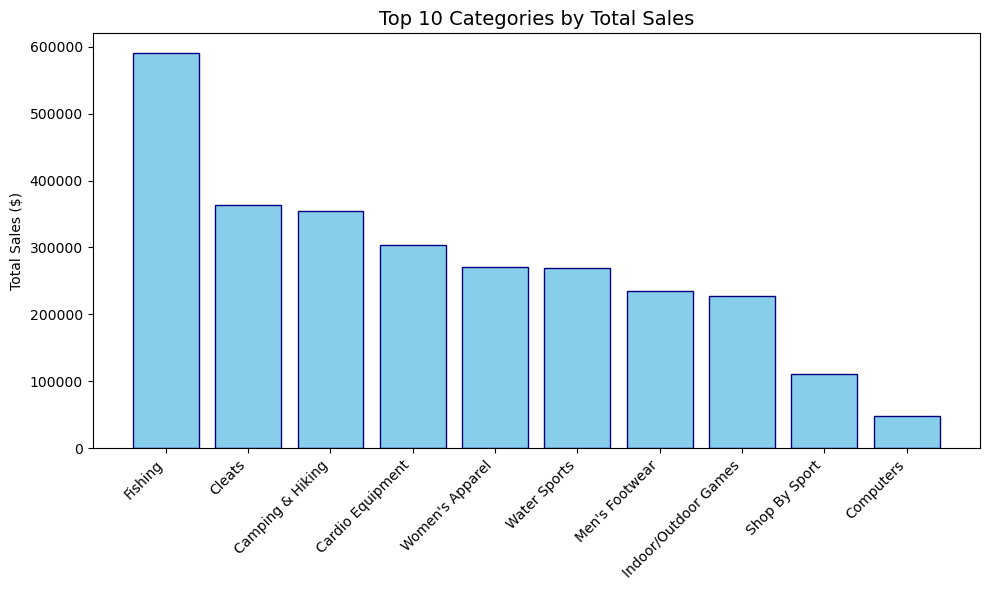

In [25]:
# Plot A: Top Categories by Sales (Bar Chart)
# Significance: Identifies high-value segments in the supply chain.
cat_sales = df.groupby('Category Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(cat_sales.index, cat_sales.values, color='skyblue', edgecolor='navy')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Categories by Total Sales', fontsize=14)
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

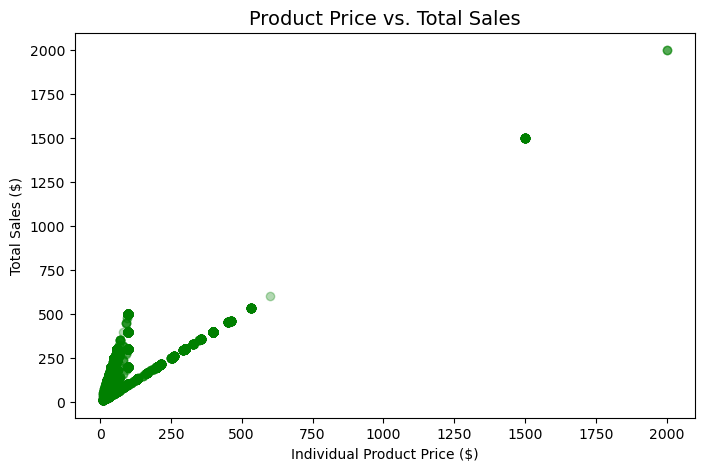

In [27]:
# Plot B: Relationship Check (Scatter Plot)
# Significance: Visualizes if 'Price' actually influence 'Sales' (Linearity).
plt.figure(figsize=(8, 5))
plt.scatter(df['Order Item Product Price'], df['Sales'], alpha=0.3, color='green')
plt.title('Product Price vs. Total Sales', fontsize=14)
plt.xlabel('Individual Product Price ($)')
plt.ylabel('Total Sales ($)')
plt.show()

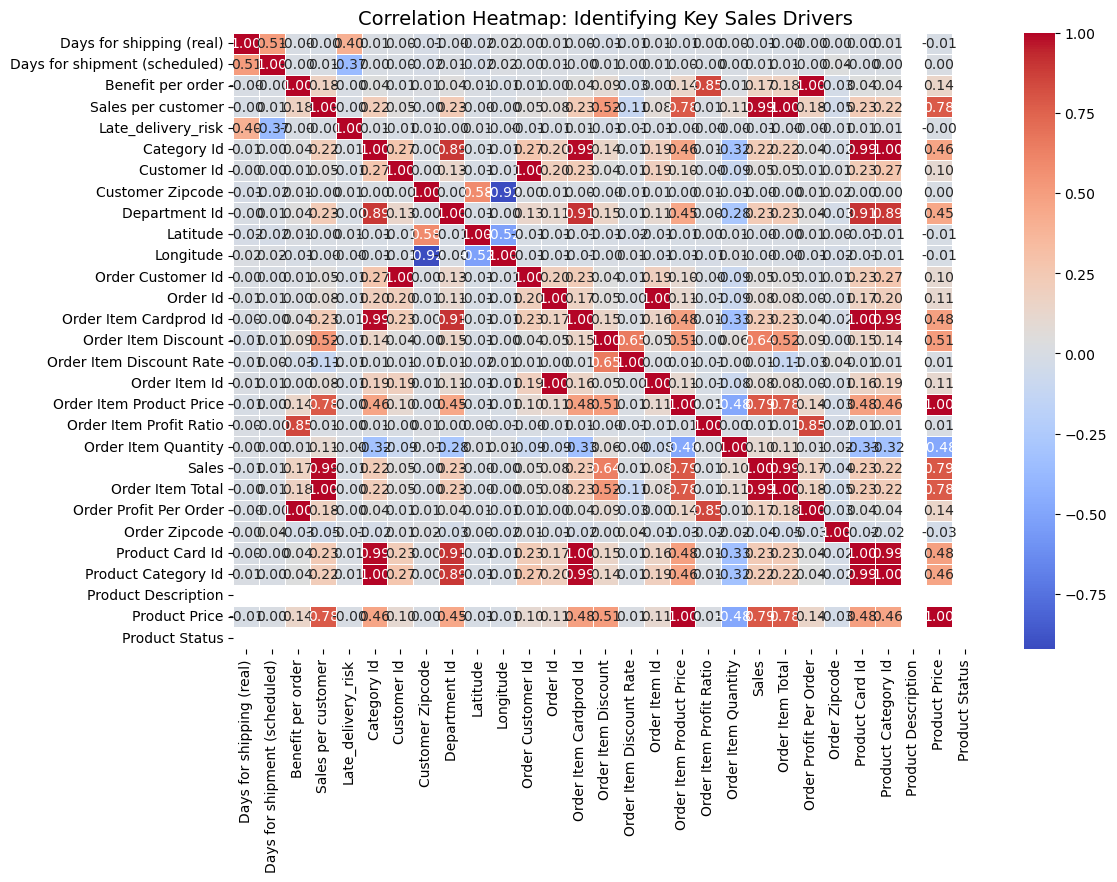

In [34]:
import seaborn as sns
# Plot C: Correlation Heatmap (Seaborn)
# Significance: Shows the mathematical strength between variables.
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap: Identifying Key Sales Drivers', fontsize=14)
plt.show()

In [35]:
# Feature Selection
features = ['Order Item Product Price', 'Order Item Quantity', 'Order Item Discount']
X = df[features].dropna()
y = df['Sales'].loc[X.index]

In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [38]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [39]:
print(f"\n--- MODEL RESULTS ---")
print(f"R-squared Score (Accuracy): {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: ${mean_absolute_error(y_test, y_pred):.2f}")


--- MODEL RESULTS ---
R-squared Score (Accuracy): 0.9314
Mean Absolute Error: $17.27


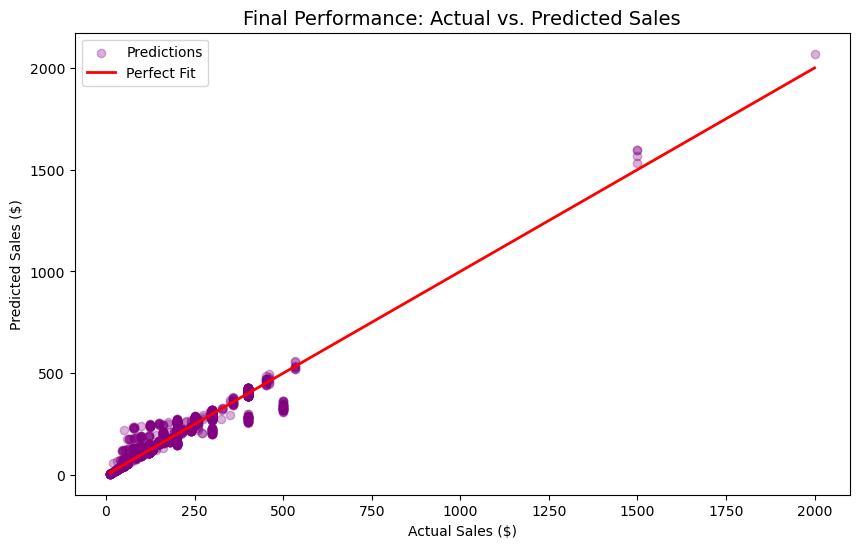

In [40]:
# Final Result Plot: Actual vs. Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='purple', alpha=0.3, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, label='Perfect Fit')
plt.title('Final Performance: Actual vs. Predicted Sales', fontsize=14)
plt.xlabel('Actual Sales ($)')
plt.ylabel('Predicted Sales ($)')
plt.legend()
plt.show()

In [49]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Train the model
modelD = DecisionTreeRegressor()
modelD.fit(X_train, y_train)

# Predict and Evaluate
y_pred = modelD.predict(X_test)

print(f"--- Decision tree Model Results ---")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f}")

--- Decision tree Model Results ---
R2 Score: 0.7536
Mean Absolute Error: 36.04


In [50]:
from sklearn.ensemble import RandomForestRegressor

In [51]:
modelR = RandomForestRegressor()
modelR.fit(X_train, y_train)

y_pred = modelR.predict(X_test)

In [52]:
print(f"\n--- RANDOM FOREST REGRESSOR RESULTS ---")
print(f"R-squared Score (Accuracy): {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: ${mean_absolute_error(y_test, y_pred):.2f}")


--- RANDOM FOREST REGRESSOR RESULTS ---
R-squared Score (Accuracy): 0.7513
Mean Absolute Error: $36.20


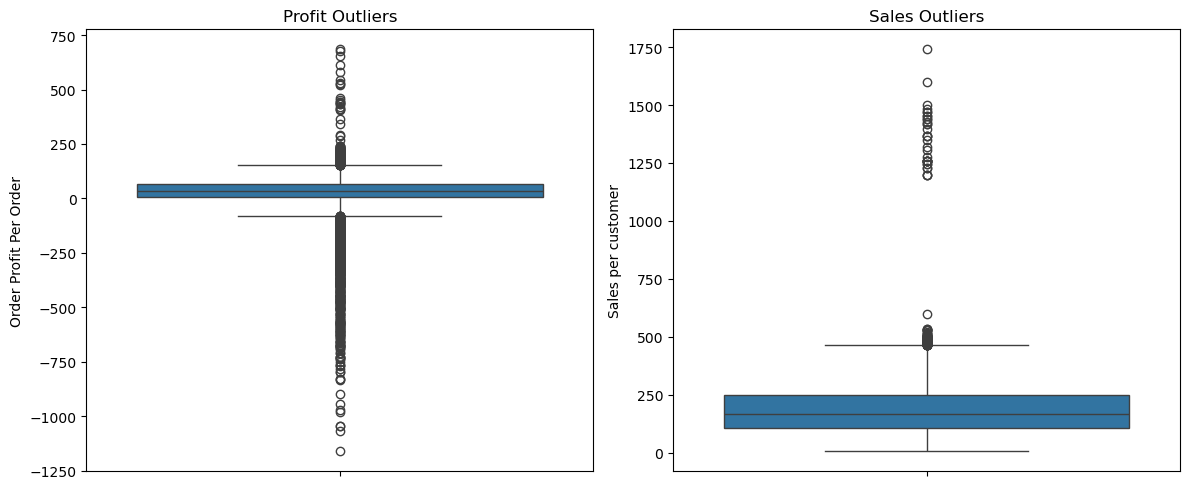

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check Profit and Sales outliers
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Order Profit Per Order'])
plt.title('Profit Outliers')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Sales per customer'])
plt.title('Sales Outliers')

plt.tight_layout()
plt.show()

In [54]:
import pandas as pd

# 1. First, define the IQR and Clean the FULL dataset 
Q1 = df['Order Profit Per Order'].quantile(0.25)
Q3 = df['Order Profit Per Order'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_cleaned = df[(df['Order Profit Per Order'] >= lower_bound) & 
                (df['Order Profit Per Order'] <= upper_bound)]

# 2. Now, create a 10,000 row sample from the cleaned data
# random_state=42 ensures you get the same 'random' rows every time you run it
df_sample = df_cleaned.sample(n=10000, random_state=42)

# 3. Validation Check: Compare Means to ensure the sample is accurate
print("--- Validation Check ---")
print(f"Original Cleaned Mean Sales: {df_cleaned['Sales'].mean():.2f}")
print(f"Sampled Mean Sales:          {df_sample['Sales'].mean():.2f}")
print(f"\nNew Dataset Size: {df_sample.shape}")

--- Validation Check ---
Original Cleaned Mean Sales: 191.68
Sampled Mean Sales:          191.79

New Dataset Size: (10000, 53)


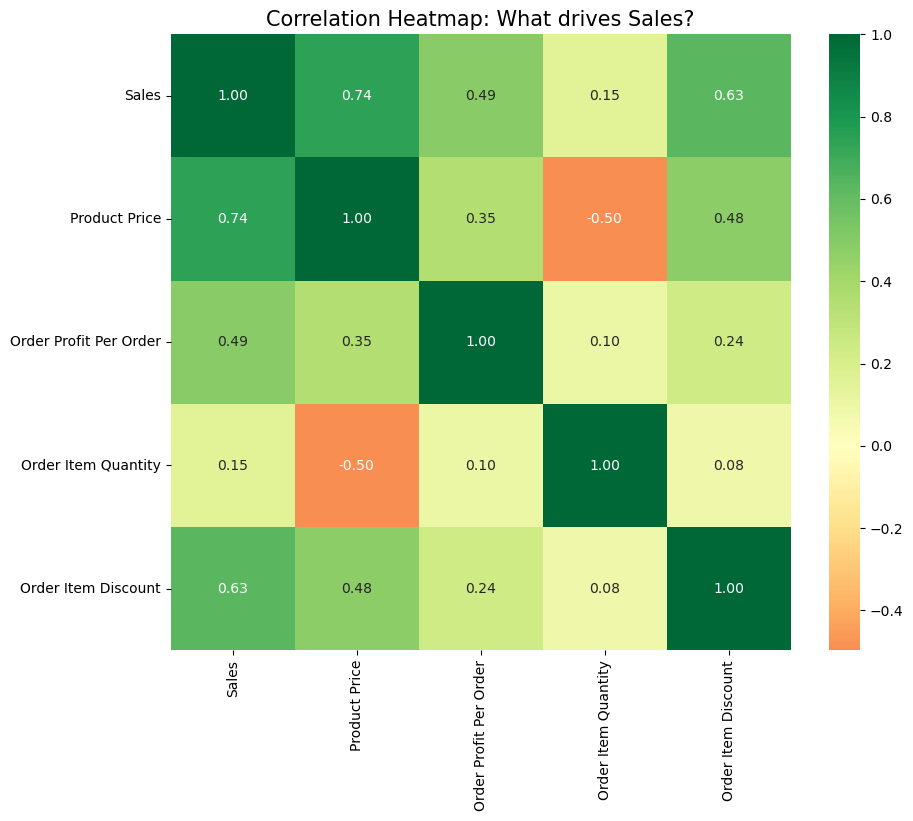

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select the key numerical columns related to your objective
# We include Price (your predictor), Sales (your target), and related factors.
cols_to_check = ['Sales', 'Product Price', 'Order Profit Per Order', 
                 'Order Item Quantity', 'Order Item Discount']

# 2. Filter the sample to these columns and calculate correlation
corr_matrix = df_sample[cols_to_check].corr()

# 3. Create the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, fmt=".2f")

plt.title('Correlation Heatmap: What drives Sales?', fontsize=15)
plt.show()

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn import metrics
import numpy as np

X = df_sample[['Product Price']]
y = df_sample['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


modelL = LinearRegression()
modelL.fit(X_train, y_train)

modelR = RandomForestRegressor()
modelR.fit(X_train, y_train)

modelD = DecisionTreeRegressor()
modelD.fit(X_train, y_train)

# 4. Make Predictions
y_pred_L = modelL.predict(X_test)
y_pred_R = modelR.predict(X_test)
y_pred_D = modelD.predict(X_test)

# 5. Evaluate the Results
r2_1 = metrics.r2_score(y_test, y_pred_L)
mae_1 = metrics.mean_absolute_error(y_test, y_pred_L)

r2_2 = metrics.r2_score(y_test, y_pred_R)
mae_2 = metrics.mean_absolute_error(y_test, y_pred_R)

r2_3 = metrics.r2_score(y_test, y_pred_D)
mae_3 = metrics.mean_absolute_error(y_test, y_pred_D)

print("--- Linear regression Model Performance ---")
print(f"R-squared Score: {r2_1:.4f}")
print(f"Mean Absolute Error: ${mae_1:.2f}")

print("\n --- Random forest Model Performance ---")
print(f"R-squared Score: {r2_2:.4f}")
print(f"Mean Absolute Error: ${mae_2:.2f}")

print("\n ---  Decision tree Model Performance ---")
print(f"R-squared Score: {r2_3:.4f}")
print(f"Mean Absolute Error: ${mae_3:.2f}")


--- Linear regression Model Performance ---
R-squared Score: 0.6109
Mean Absolute Error: $56.95

 --- Random forest Model Performance ---
R-squared Score: 0.7509
Mean Absolute Error: $36.22

 ---  Decision tree Model Performance ---
R-squared Score: 0.7536
Mean Absolute Error: $36.04


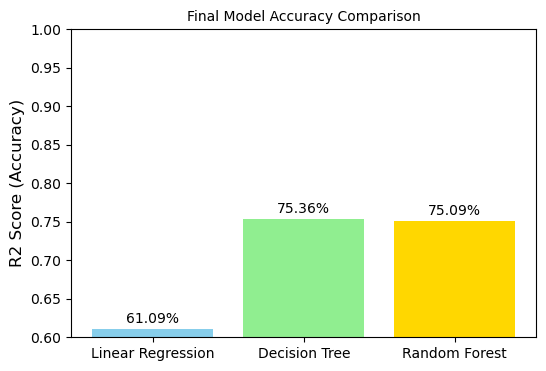

In [62]:
import matplotlib.pyplot as plt

# 1. Prepare the data
model_names = ['Linear Regression', 'Decision Tree', 'Random Forest']
scores = [0.6109, 0.7536, 0.7509]

# 2. Create the bar chart
plt.figure(figsize=(6, 4))
bars = plt.bar(model_names, scores, color=['skyblue', 'lightgreen', 'gold'])

# 3. Add labels and a title
plt.title('Final Model Accuracy Comparison', fontsize=10)
plt.ylabel('R2 Score (Accuracy)', fontsize=12)
plt.ylim(0.6, 1.0) 

# Add the percentage labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.004, f'{yval*100:.2f}%', ha='center', va='bottom')

plt.show()